# Step 1: Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
with open("./traffic-signs-data/train.p", mode = 'rb') as training_data:
    train = pickle.load(training_data)
with open("./traffic-signs-data/valid.p", mode = 'rb') as validation_data:
    valid = pickle.load(validation_data)
with open("./traffic-signs-data/test.p", mode = 'rb') as testing_data:
    test = pickle.load(testing_data)

In [3]:
X_train, y_train = train['features'], train['labels']
X_validation, y_validation = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

In [4]:
X_train.shape

(34799, 32, 32, 3)

In [5]:
y_train.shape

(34799,)

In [6]:
X_validation.shape

(4410, 32, 32, 3)

In [7]:
X_test.shape

(12630, 32, 32, 3)

In [8]:
y_test.shape

(12630,)

# Step 2: Image Exploration

np.uint8(36)

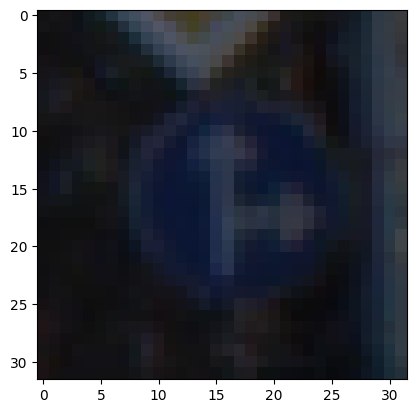

In [9]:
i = 1000
plt.imshow(X_train[i])
y_train[i]

np.uint8(17)

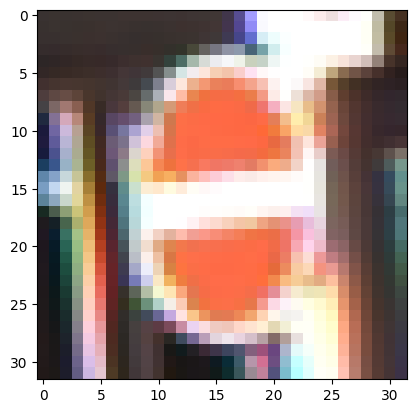

In [10]:
i = 4000
plt.imshow(X_validation[i])
y_validation[i]

np.uint8(11)

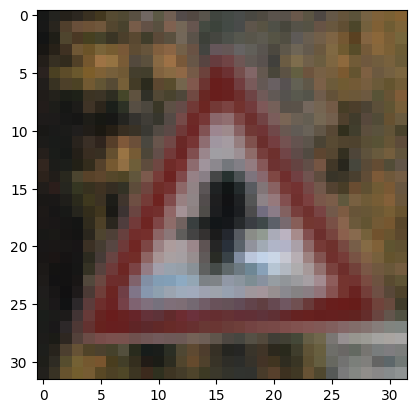

In [11]:
i = 3000
plt.imshow(X_test[i])
y_test[i]

# Step 3: Data Prepration

In [12]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train)

In [13]:
X_train_gray = np.sum(X_train / 3, axis = 3, keepdims = True)
X_test_gray = np.sum(X_test / 3, axis = 3, keepdims = True)
X_validation_gray = np.sum(X_validation / 3, axis = 3, keepdims = True)

In [14]:
X_train_gray.shape

(34799, 32, 32, 1)

In [15]:
X_test_gray.shape

(12630, 32, 32, 1)

In [16]:
X_validation.shape

(4410, 32, 32, 3)

In [17]:
X_train_gray_norm = (X_train_gray - 128 ) / 128
X_test_gray_norm = (X_test_gray - 128) / 128
X_validation_gray_norm = (X_validation_gray - 128) / 128

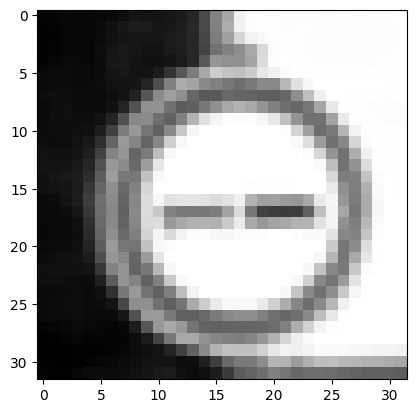

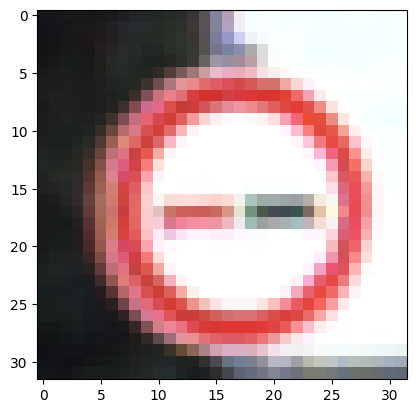

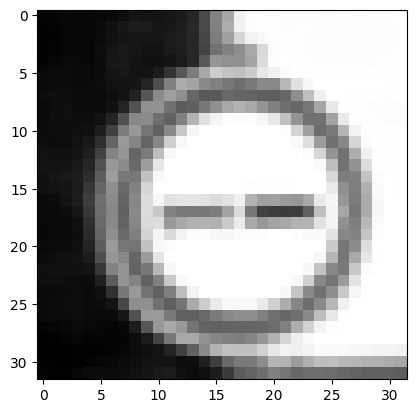

In [18]:
i = 1200
plt.imshow(X_train_gray[i].squeeze(), cmap = 'gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray_norm[i].squeeze(), cmap = 'gray')

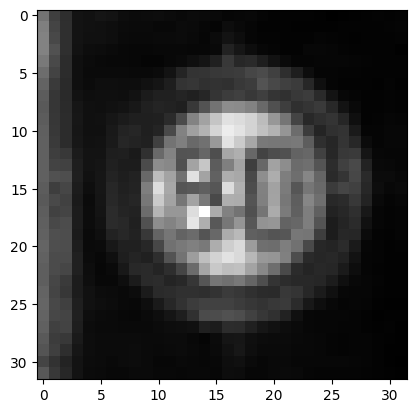

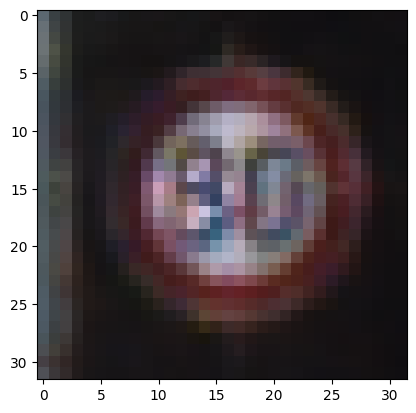

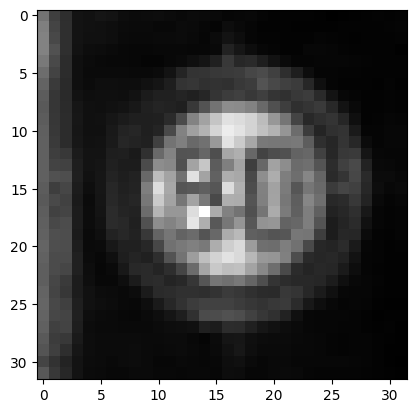

In [19]:
i = 1200
plt.imshow(X_test_gray[i].squeeze(), cmap = 'gray')
plt.figure()
plt.imshow(X_test[i])
plt.figure()
plt.imshow(X_test_gray_norm[i].squeeze(), cmap = 'gray')

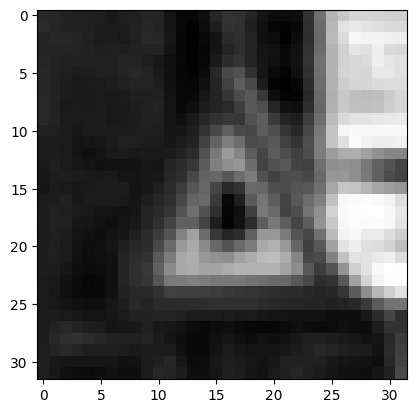

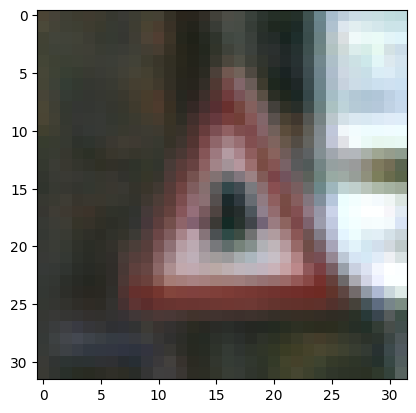

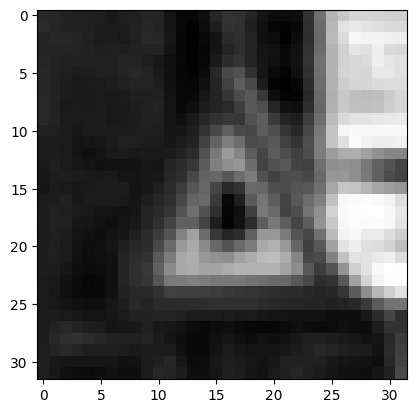

In [20]:
i = 1200
plt.imshow(X_validation_gray[i].squeeze(), cmap = 'gray')
plt.figure()
plt.imshow(X_validation[i])
plt.figure()
plt.imshow(X_validation_gray_norm[i].squeeze(), cmap = 'gray')

# Step 4: Model Training

In [24]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Dense, Flatten, Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [26]:
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Input

cnn_model = Sequential()
cnn_model.add(Input(shape=(32, 32, 1)))  

cnn_model.add(Conv2D(filters=6, kernel_size=(5, 5), activation='relu'))
cnn_model.add(AveragePooling2D(pool_size=(2, 2)))

cnn_model.add(Conv2D(filters=6, kernel_size=(5, 5), activation='relu'))
cnn_model.add(AveragePooling2D(pool_size=(2, 2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(units=120, activation='relu'))
cnn_model.add(Dense(units=84, activation='relu'))
cnn_model.add(Dense(units=43, activation='softmax'))

In [28]:
from keras.optimizers import Adam

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [31]:
history = cnn_model.fit(
    X_train_gray_norm, 
    y_train, 
    batch_size=500, 
    epochs=5,  
    verbose=1, 
    validation_data=(X_validation_gray_norm, y_validation)
)

Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8489 - loss: 0.5448 - val_accuracy: 0.7465 - val_loss: 0.8867
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.8704 - loss: 0.4745 - val_accuracy: 0.7728 - val_loss: 0.8281
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8840 - loss: 0.4257 - val_accuracy: 0.7746 - val_loss: 0.8334
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9024 - loss: 0.3700 - val_accuracy: 0.7939 - val_loss: 0.7780
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9100 - loss: 0.3292 - val_accuracy: 0.7930 - val_loss: 0.7499


# Step 5: Model Evaluation

In [32]:
score = cnn_model.evaluate(X_test_gray_norm, y_test)
print('Test Accuracy: {}'.format(score[1]))

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7820 - loss: 0.9909
Test Accuracy: 0.7826603055000305


In [33]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [34]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

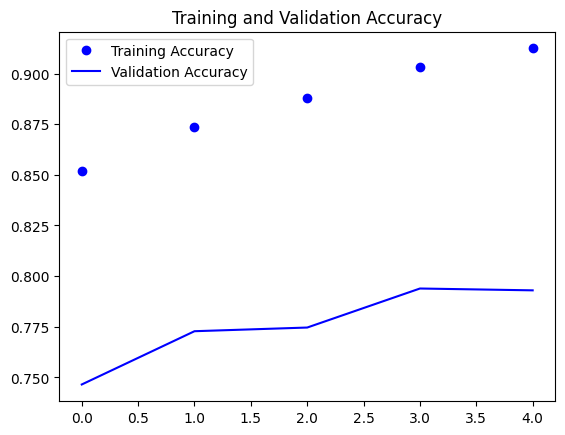

In [38]:
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

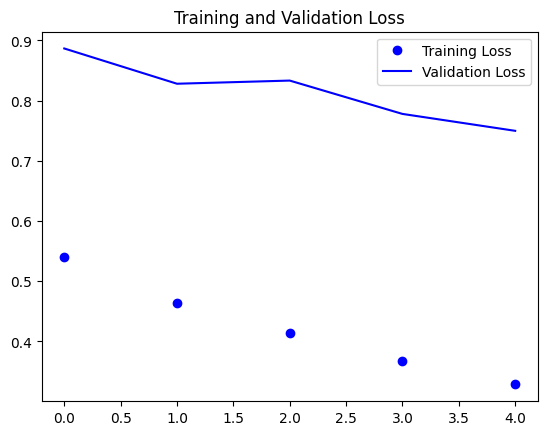

In [39]:
epochs = range(len(accuracy))
plt.plot(epochs, loss, 'bo', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [43]:
predictions = cnn_model.predict(X_test_gray_norm)
predicted_classes = np.argmax(predictions, axis=1)
y_true = y_test


395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Axes: >

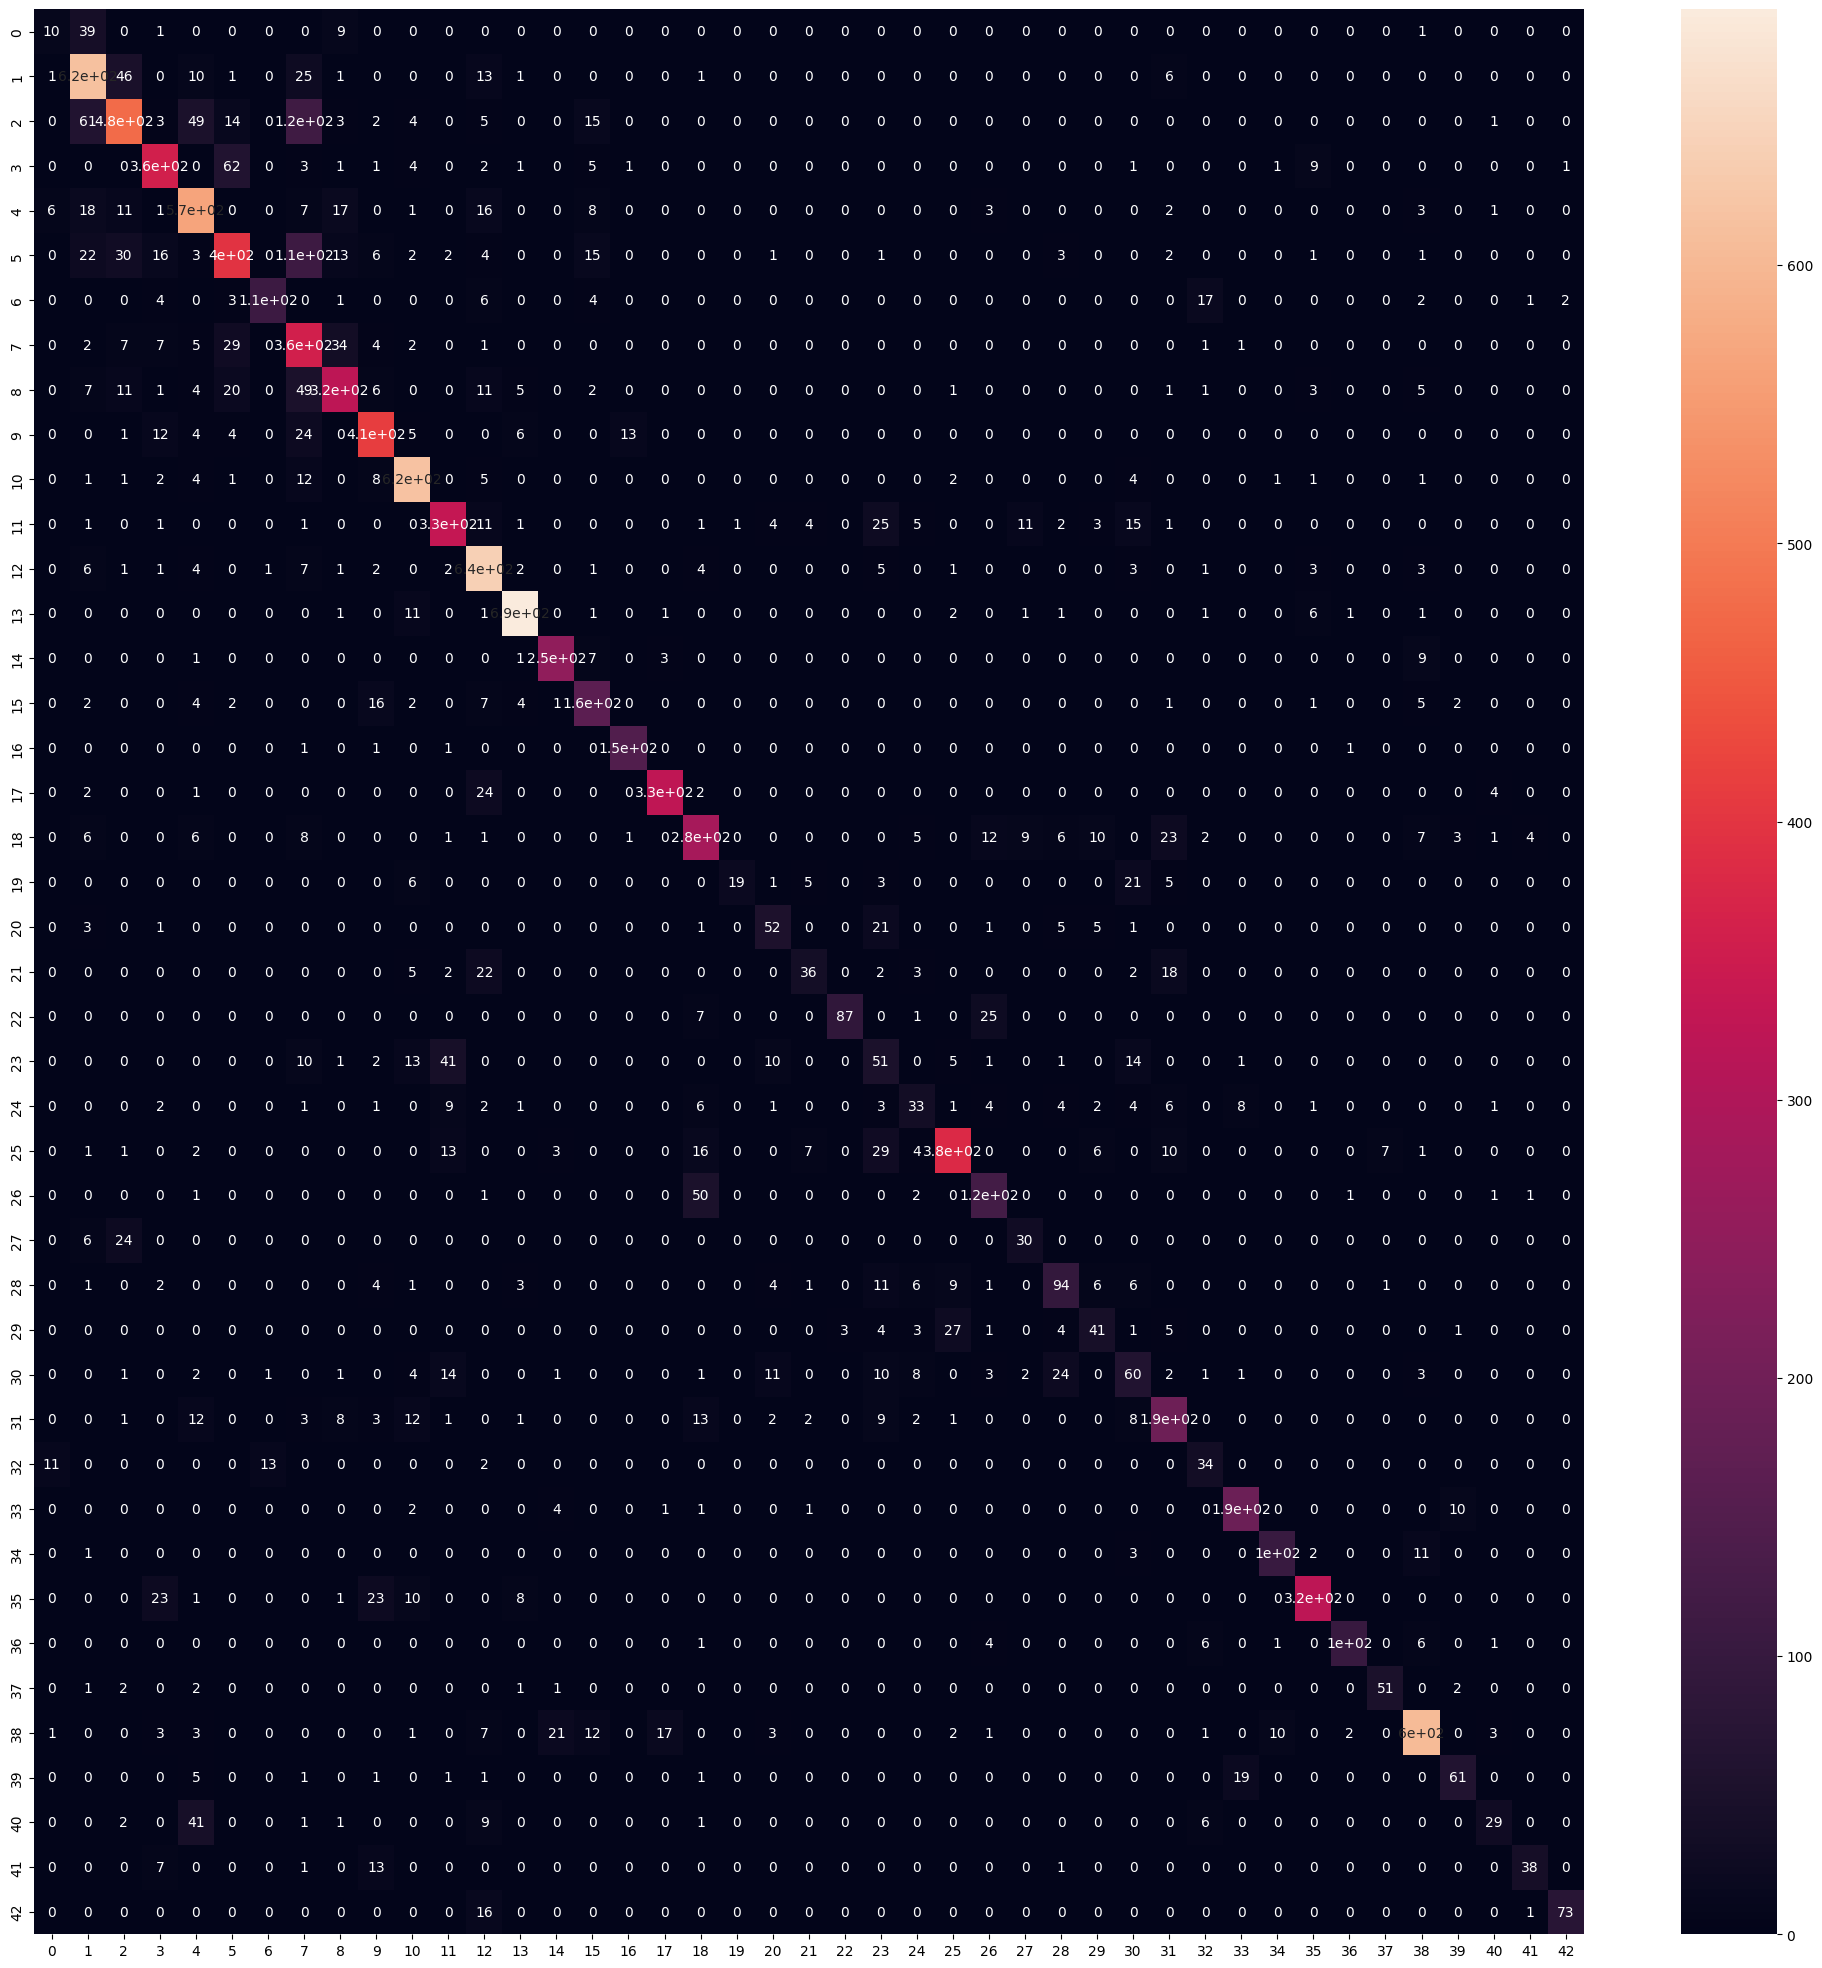

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize= (25, 25))
sns.heatmap(cm, annot = True)

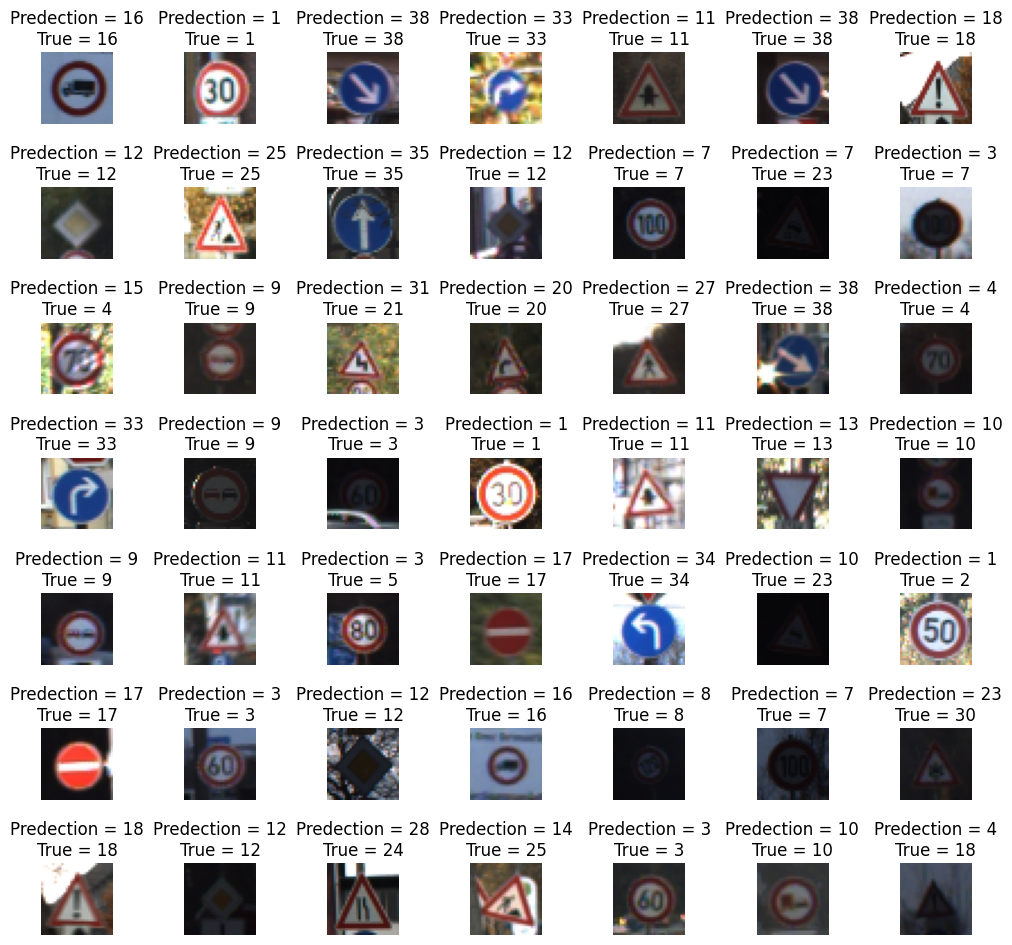

In [48]:
L = 7
W = 7
fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes .ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Predection = {}\nTrue = {}'.format(predicted_classes[i], y_true[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace= 1)